In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("telco_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**EDA % Cleaing**

In [2]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(7043, 21)

In [7]:
df = df.drop(columns=['customerID'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors="coerce")

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

for col in df.columns:
    df[col] = df[col].replace("No phone service","No")
    df[col] = df[col].replace("No internet service" , "No")


In [8]:
Q1 = df['TotalCharges'].quantile(.25)
Q3 = df['TotalCharges'].quantile(.75)
IQR = Q3 - Q1
lower = max(0 , Q1 - 1.5*IQR)
upper = Q3 + 1.5*IQR
print(f"Price Lower Bound : {lower}")

print(f"Price Upper Bound : {upper}")

Price Lower Bound : 0
Price Upper Bound : 8863.1625


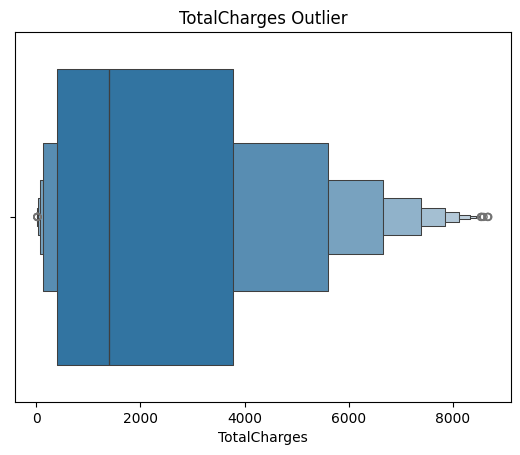

In [9]:
sns.boxenplot(data=df , x='TotalCharges')
plt.title("TotalCharges Outlier")
plt.show()

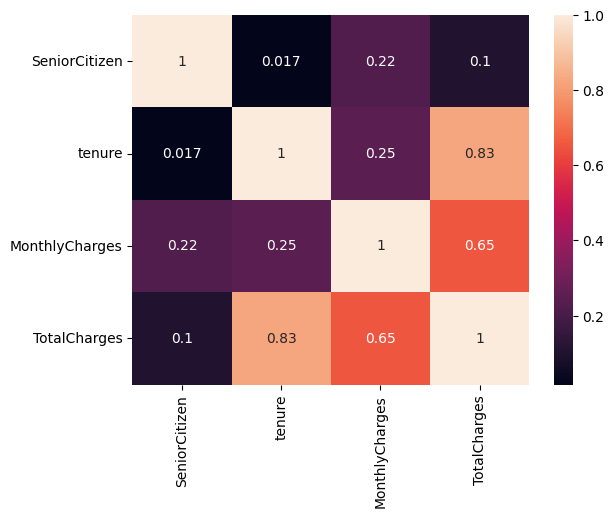

In [10]:
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
corr = df[num_cols].corr()
sns.heatmap(corr , annot=True)
plt.show()

**Visualization**

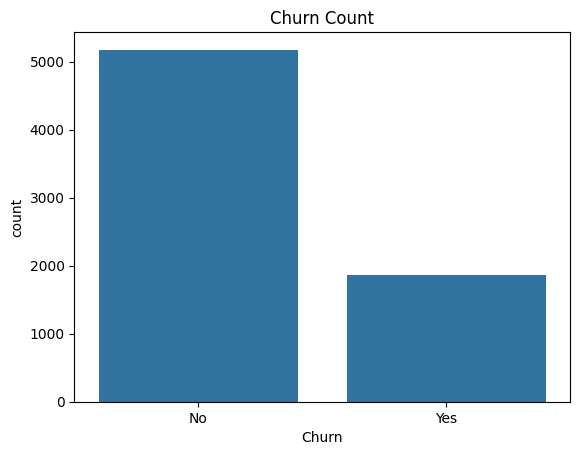

In [11]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Count")
plt.show()

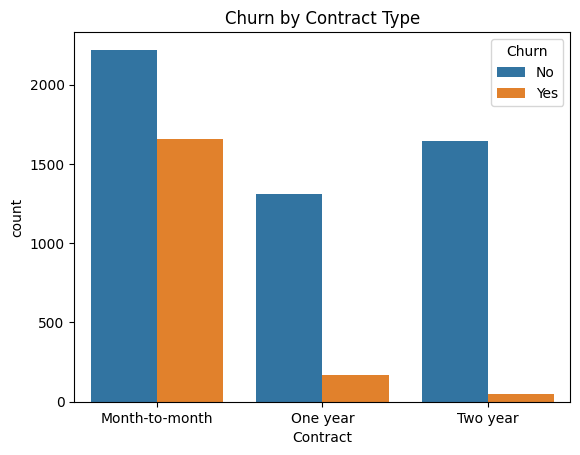

In [12]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

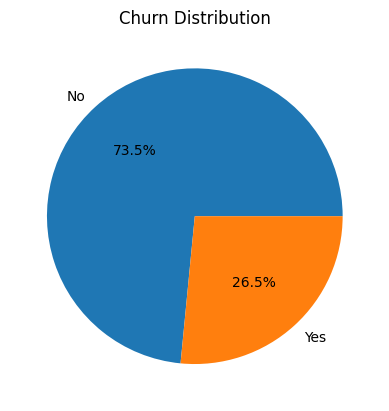

In [13]:
churn = df['Churn'].value_counts()
plt.pie(churn , labels=churn.index , autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()

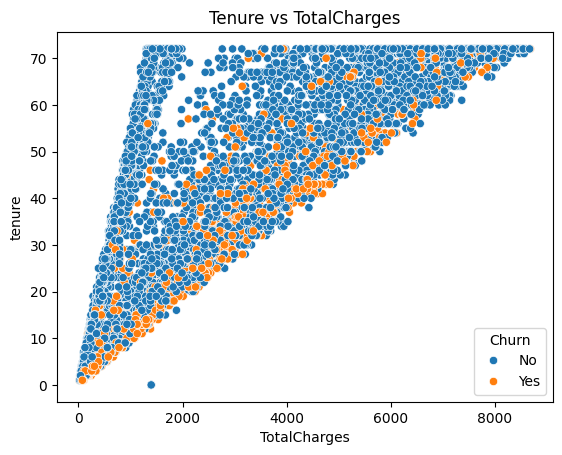

In [14]:
sns.scatterplot(data=df , x='TotalCharges' ,y='tenure',hue='Churn')
plt.title("Tenure vs TotalCharges")
plt.show()

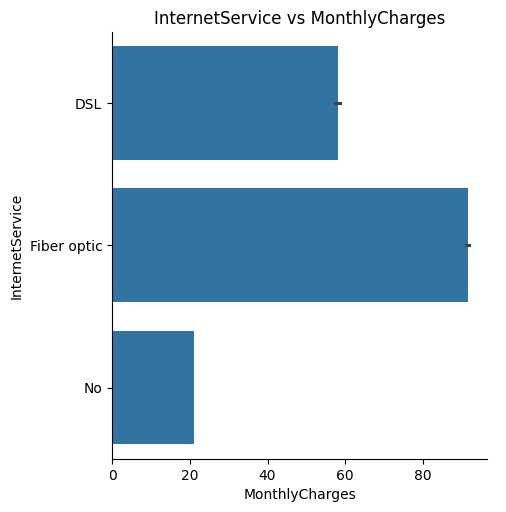

In [15]:
sns.catplot(x="MonthlyCharges",y='InternetService',data=df,kind='bar')
plt.title("InternetService vs MonthlyCharges")
plt.show()

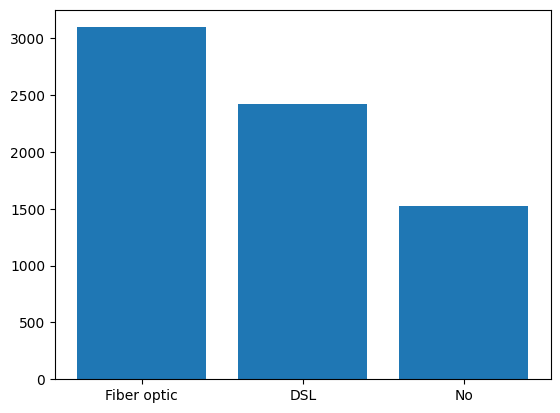

In [16]:
counts = df['InternetService'].value_counts()
plt.bar(counts.index,counts.values)
plt.show()

**Preprocessing**


In [17]:
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# df = df.drop(columns=cat_cols)
df


C:\Users\ENG_IBRAHIM_WAHBA\AppData\Local\Temp\ipykernel_27780\629198947.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,0,0,1,0,1,1,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,0,1,0,1,1,1,1,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,1,1,0,1,1,0,1,1,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,0,0,1,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,1,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [19]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,train_size=0.20,random_state=42,stratify=y)

print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (1408, 19)  y_train =  (1408,)
X_test  =  (5635, 19)  y_test  =  (5635,)


In [20]:
from sklearn.preprocessing import MinMaxScaler
my_scaler = MinMaxScaler(feature_range=(0,1))
X_train = my_scaler.fit_transform(X_train)
X_test = my_scaler.transform(X_test)

**Logistic Regression**

In [21]:
from sklearn.linear_model import LogisticRegression
logRreg_model = LogisticRegression(max_iter=1000,solver='liblinear')
logRreg_model.fit(X_train , y_train)
y_pred_log = logRreg_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

print("==== Logistic Regression ====")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_log))
print("\nClassification Report:\n",classification_report(y_test, y_pred_log))
cm_log_model = confusion_matrix(y_test , y_pred_log)
print("Confusion Matrix:\n",cm_log_model)

log_acc = accuracy_score(y_test, y_pred_log)

==== Logistic Regression ====
Accuracy : 0.7927240461401952
Precision: 0.6222887060583395
Recall   : 0.5565217391304348
F1 Score : 0.5875706214689266
ROC AUC  : 0.7172705314009661

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86      4140
           1       0.62      0.56      0.59      1495

    accuracy                           0.79      5635
   macro avg       0.73      0.72      0.72      5635
weighted avg       0.79      0.79      0.79      5635

Confusion Matrix:
 [[3635  505]
 [ 663  832]]


**Random Forest**

In [23]:
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

rF_model = RandomForestClassifier(n_estimators=25 , max_depth=10 , criterion='entropy' , random_state=42 , max_features='sqrt' , bootstrap=True)
rF_model.fit(X_train ,y_train)

y_pred_rF = rF_model.predict(X_test)


In [24]:
print("========= Random Forest =========")
print("Accuracy :", accuracy_score(y_test, y_pred_rF))
print("Precision:", precision_score(y_test, y_pred_rF))
print("Recall   :", recall_score(y_test, y_pred_rF))
print("F1 Score :", f1_score(y_test, y_pred_rF))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_rF))
print("\nClassification Report:\n",classification_report(y_test, y_pred_rF))
cm_rf_model = confusion_matrix(y_test , y_pred_rF)
print("Confusion Matrix:\n",cm_rf_model)

rf_acc = accuracy_score(y_test, y_pred_rF)

========= Random Forest =========
Accuracy : 0.7920141969831411
Precision: 0.6243264049268669
Recall   : 0.5424749163879599
F1 Score : 0.5805297065139585
ROC AUC  : 0.7123002601263471

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      4140
           1       0.62      0.54      0.58      1495

    accuracy                           0.79      5635
   macro avg       0.73      0.71      0.72      5635
weighted avg       0.78      0.79      0.79      5635

Confusion Matrix:
 [[3652  488]
 [ 684  811]]


In [25]:
if rf_acc >= log_acc:
    best_model = rF_model
    print("\nBest model: Random Forest")
else:
    best_model = logRreg_model
    print("\nBest model: Logistic Regression")


Best model: Logistic Regression


**Deployment**

In [26]:
import pickle
with open("model_lr.pkl", "wb") as file:
    pickle.dump(logRreg_model , file)

with open("model_rf.pkl", "wb") as file:
    pickle.dump(rF_model , file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(my_scaler, file)

with open("columns.pkl", "wb") as file:
    pickle.dump(list(X.columns), file)

print("\nModels saved successfully ✅")


Models saved successfully ✅
